In [12]:
import pandas as pd
df = pd.read_csv('data/student_performance_data.csv')

# First look at the data

In [13]:
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


# Info on the data

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  str    
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  str    
 9   extra_classes          10000 non-null  str    
 10  parent_education       10000 non-null  str    
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  str    
dtypes: float64(8), int64(1), str(5)
memory usage: 1.1 MB


# Summary Stats

In [15]:
df.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


# Shape of data

In [16]:
print("Rows, Columns:", df.shape)

Rows, Columns: (10000, 14)


# Are there any duplicates? After reviewing the code: no

In [17]:
print(df.duplicated().sum())

0


# Check current data types. They are properly assigned

In [18]:

print(df.dtypes)

student_id                 int64
gender                       str
study_hours_per_day      float64
attendance_percentage    float64
assignment_score         float64
midterm_score            float64
final_exam_score         float64
participation_score      float64
internet_access              str
extra_classes                str
parent_education             str
sleep_hours              float64
overall_score            float64
grade                        str
dtype: object


# Check for missing values. No missing values

In [19]:
print(df.isnull().sum())

student_id               0
gender                   0
study_hours_per_day      0
attendance_percentage    0
assignment_score         0
midterm_score            0
final_exam_score         0
participation_score      0
internet_access          0
extra_classes            0
parent_education         0
sleep_hours              0
overall_score            0
grade                    0
dtype: int64


# Stripping extra spaces off string columns

In [20]:
category_columns = ['gender', 'internet_access','extra_classes','parent_education','grade']

for col in category_columns:
    df[col] = df[col].astype(str).str.strip()

# Usually Yes/No are not standard values in a database. Updating the mapping for internet access and extra classes to be 1 and 0 vs Yes and No.

In [21]:
df['internet_access'] = df['internet_access'].map({'Yes':1, 'No':0})

In [22]:
df['extra_classes'] = df['extra_classes'].map({'Yes':1, 'No':0})

# Checking the columns after stripping them and reassigning values

In [23]:
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,1,0,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,0,1,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,0,1,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,0,0,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,0,0,Bachelor,8.59,65.6005,C


# Generating a boxpolot to check the data for outliers. (A few in overall score). This chart is meant to be simple with minimal colors purely to show outliers in the dataset. Boxplot is great for this.

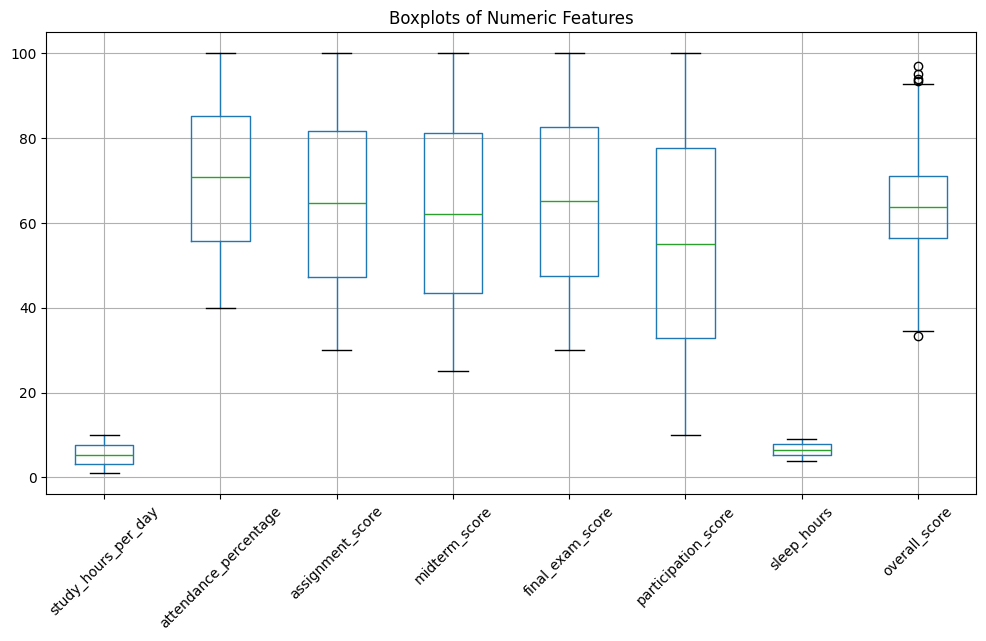

In [24]:
import matplotlib.pyplot as plt

columns_to_plot = ['study_hours_per_day','attendance_percentage', 'assignment_score','midterm_score','final_exam_score', 'participation_score','sleep_hours','overall_score']

df[columns_to_plot].boxplot(figsize=(12,6))

plt.xticks(rotation=45)
plt.title("Boxplots of Numeric Features")
plt.show()


# Adding a correlation plot. The coolwarm colors clearly show the where the correlation is strong. Again I am analyzing the data to look for questions I can start to ask or solve with the data.  There is the highest correlation between overall score and final exam score

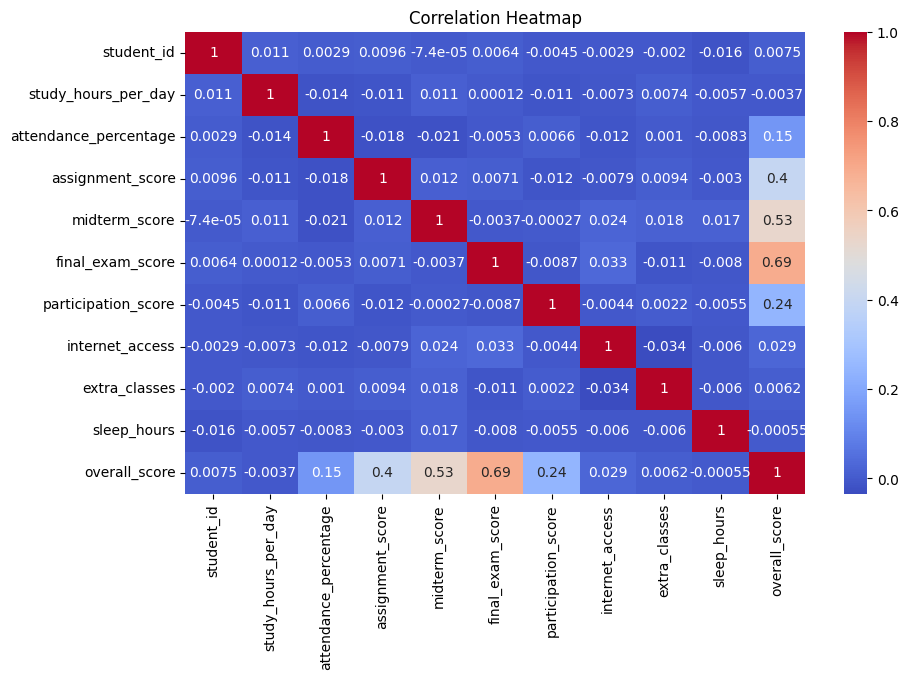

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap( df.corr(numeric_only=True), annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Adding a histogram to check the distribution of the data. Its a pretty even spread across categories. I am starting to suspect the data is synthetic and seeing the perfect bell curve below for student scores kind of confirms this. Considering adding another dataset later on from the real world.

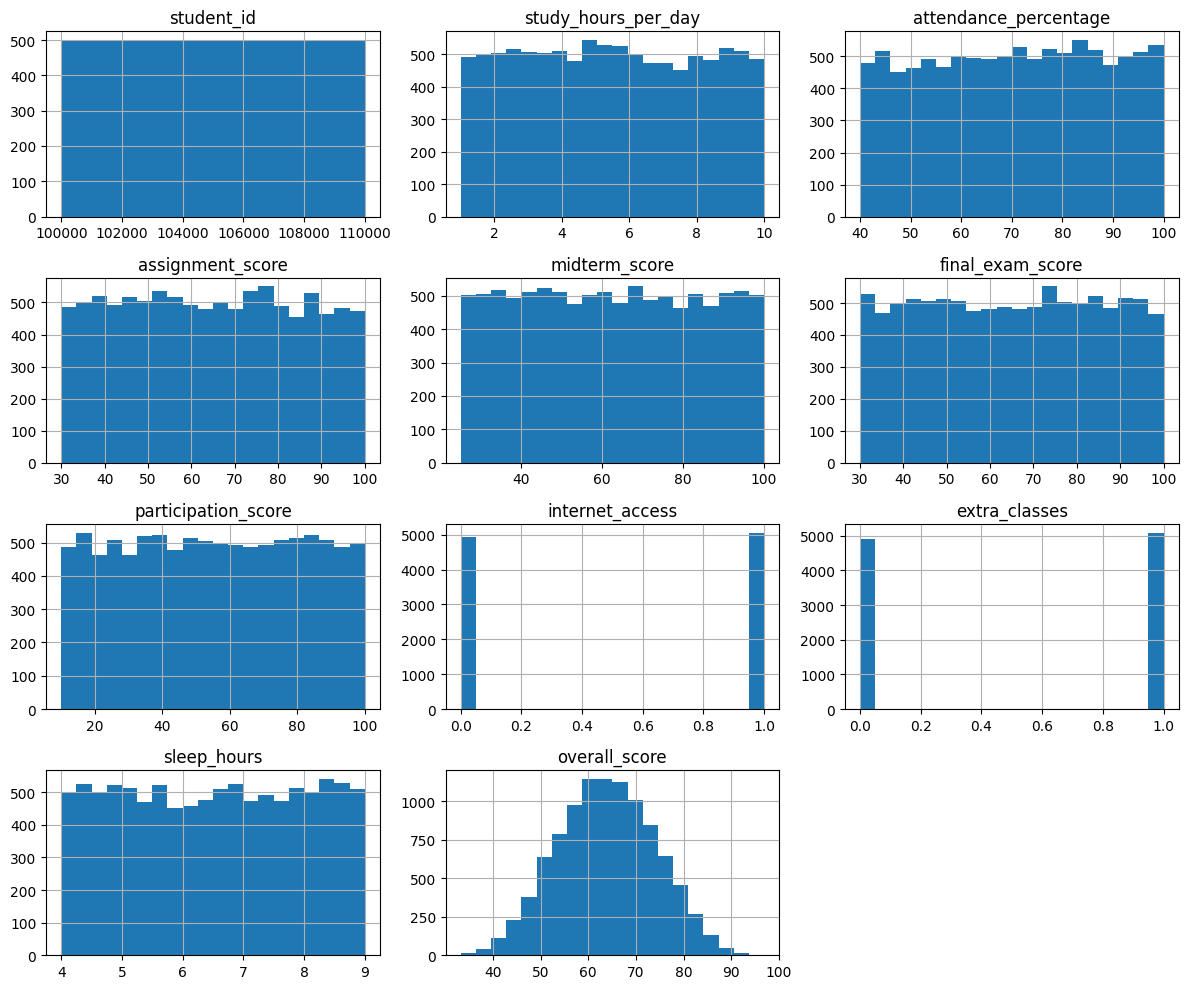

In [26]:
df.hist(figsize=(12,10), bins=20)

plt.tight_layout()
plt.show()

# Below are some summary values to start analyzing the data. I am not seeing much difference between parent education level and score or gender and score or internet access and score.

In [27]:
gender_avg = df.groupby('gender')['overall_score'].mean()

print(gender_avg)

gender
Female    63.830053
Male      63.823766
Name: overall_score, dtype: float64


In [28]:
parent_avg = df.groupby('parent_education')['overall_score'].mean()

print(parent_avg.sort_values(ascending=False))

parent_education
Bachelor       64.008239
Master         63.920976
High School    63.753196
PhD            63.621093
Name: overall_score, dtype: float64


In [29]:
internet_summary = df.groupby('internet_access')['overall_score'].mean()

print(internet_summary)

internet_access
0    63.525771
1    64.120773
Name: overall_score, dtype: float64


In [30]:
top_students = df.sort_values(
    by='overall_score',
    ascending=False
)

print(top_students.head(10))

      student_id  gender  study_hours_per_day  attendance_percentage  \
5745      105745    Male                 6.22                  98.96   
8453      108453    Male                 2.55                  98.61   
7374      107374  Female                 9.21                  91.41   
3598      103598  Female                 5.68                  81.95   
4667      104667  Female                 2.97                  47.49   
12        100012    Male                 5.82                  99.06   
7472      107472  Female                 3.63                  91.97   
7667      107667    Male                 7.83                  92.88   
8563      108563  Female                 6.01                  94.83   
2135      102135    Male                 7.65                  97.13   

      assignment_score  midterm_score  final_exam_score  participation_score  \
5745             96.15          99.64             97.79                86.17   
8453             88.66          98.96          

In [31]:
summary_table = df.groupby('grade').agg({ 'overall_score': ['mean', 'min', 'max'],  'study_hours_per_day': 'mean',  'attendance_percentage': 'mean',  'sleep_hours': 'mean'})

print(summary_table)

      overall_score                   study_hours_per_day  \
               mean      min      max                mean   
grade                                                       
A         87.579114  85.0175  96.8795            5.293377   
B         75.512695  70.0085  84.9915            5.507955   
C         62.665668  55.0025  69.9980            5.436976   
D         49.993153  40.0510  54.9985            5.507719   
F         37.808434  33.2635  39.9570            5.381639   

      attendance_percentage sleep_hours  
                       mean        mean  
grade                                    
A                 78.894221    6.472987  
B                 73.192470    6.504109  
C                 70.294642    6.501961  
D                 67.113984    6.522605  
F                 57.482295    6.325574  


# Charting Attendance against grade to see if there is any correlation. (Those with A's had the highest attendance.) I picked the colors and the size to keep a professional clean look.

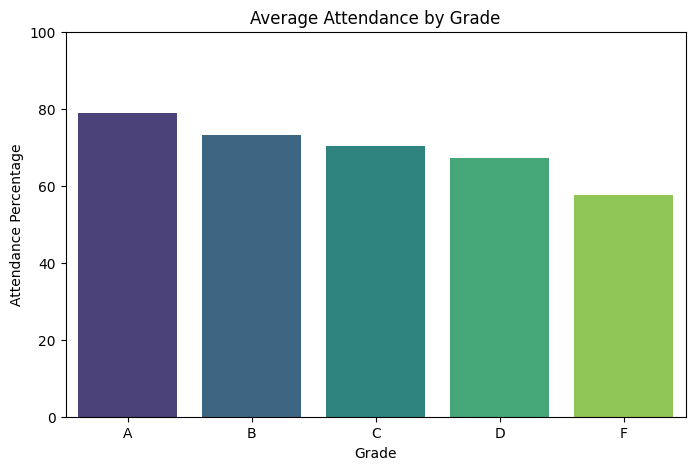

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

grade_attendance = df.groupby('grade')['attendance_percentage'].mean().reset_index()
plt.figure(figsize=(8,5))

sns.barplot(
    data=grade_attendance,
    x='grade',
    y='attendance_percentage',
    palette='viridis',
    hue = 'grade'
)

plt.title("Average Attendance by Grade")
plt.xlabel("Grade")
plt.ylabel("Attendance Percentage")

plt.ylim(0, 100)

plt.show()

### Adding in a 2nd dataset from the College Board bc the first dataset is cool but seems "too perfect" almost manufactured by Kaggle. The first data frame i created is for institutions

In [33]:
import pandas as pd
df_inst= pd.read_csv('data/Most-Recent-Cohorts-Institution.csv', low_memory=False)

In [34]:
df_inst.head()

,UNITID,OPEID,OPEID6,INSTNM,CITY,STABBR,ZIP,ACCREDAGENCY,INSTURL,NPCURL,...,MD_EARN_WNE_INC1_P11,MD_EARN_WNE_INC2_P11,MD_EARN_WNE_INC3_P11,MD_EARN_WNE_INDEP0_P11,MD_EARN_WNE_INDEP1_P11,MD_EARN_WNE_MALE0_P11,MD_EARN_WNE_MALE1_P11,SCORECARD_SECTOR,EARN_THR_STATE,EARN_THR_NAT
0,100654,100200.0,1002.0,Alabama A & M University,Normal,AL,35762,Southern Association of Colleges and Schools C...,www.aamu.edu/,www.aamu.edu/admissions-aid/tuition-fees/net-p...,...,36650.0,41070.0,47016.0,38892.0,41738.0,38167.0,40250.0,4,30168.0,32842
1,100663,105200.0,1052.0,University of Alabama at Birmingham,Birmingham,AL,35294-0110,Southern Association of Colleges and Schools C...,https://www.uab.edu/,https://tcc.ruffalonl.com/University of Alabam...,...,47182.0,51896.0,54368.0,50488.0,51505.0,46559.0,59181.0,4,30168.0,32842
2,100690,2503400.0,25034.0,Amridge University,Montgomery,AL,36117-3553,Southern Association of Colleges and Schools C...,https://www.amridgeuniversity.edu/,https://www2.amridgeuniversity.edu:9091/,...,35752.0,41007.0,NaN,NaN,38467.0,32654.0,49435.0,5,30168.0,32842
3,100706,105500.0,1055.0,University of Alabama in Huntsville,Huntsville,AL,35899,Southern Association of Colleges and Schools C...,www.uah.edu/,uah.clearcostcalculator.com/student/default/ne...,...,51208.0,62219.0,62577.0,55920.0,60221.0,47787.0,67454.0,4,30168.0,32842
4,100724,100500.0,1005.0,Alabama State University,Montgomery,AL,36104-0271,Southern Association of Colleges and Schools C...,www.alasu.edu/,tcc.ruffalonl.com/Alabama State University/Fre...,...,32844.0,36932.0,37966.0,34294.0,31797.0,32303.0,36964.0,4,30168.0,32842


In [35]:
df_inst.info()

<class 'pandas.DataFrame'>
RangeIndex: 6322 entries, 0 to 6321
Columns: 3308 entries, UNITID to EARN_THR_NAT
dtypes: float64(933), int64(15), str(2360)
memory usage: 159.6 MB


### Checking for duplicate records. There are none

In [36]:
print(df_inst.duplicated().sum())

0


### Checking for null records and can see several columns have nulls

In [37]:
print(df_inst.isnull().sum())

UNITID                      0
OPEID                      27
OPEID6                     27
INSTNM                      0
CITY                        0
                         ... 
MD_EARN_WNE_MALE0_P11    1587
MD_EARN_WNE_MALE1_P11    2177
SCORECARD_SECTOR            0
EARN_THR_STATE             11
EARN_THR_NAT                0
Length: 3308, dtype: int64


### Filling Na with Spaces instead

In [38]:
df = df_inst.fillna("")

### Checking for Na again and they are gone

In [39]:
print(df_inst.isna().sum())

UNITID                      0
OPEID                      27
OPEID6                     27
INSTNM                      0
CITY                        0
                         ... 
MD_EARN_WNE_MALE0_P11    1587
MD_EARN_WNE_MALE1_P11    2177
SCORECARD_SECTOR            0
EARN_THR_STATE             11
EARN_THR_NAT                0
Length: 3308, dtype: int64


### Created a python dictionary with the help of Claude AI

In [40]:
INST_COLUMNS = {
    'UNITID':          'school_id',
    'INSTNM':          'school_name',
    'STABBR':          'state',
    'REGION':          'region_code',
    'CONTROL':         'control_type',
    'PREDDEG':         'predominant_degree',
    'LOCALE':          'locale_type',
    'UGDS':            'undergrad_enrollment',
    'UGDS_MEN':        'undergrad_men',
    'UGDS_WOMEN':      'undergrad_women',
    'PCTPELL':         'pct_pell_recipients',
    'FAMINC':          'median_family_income',
    'TUITIONFEE_IN':   'tuition_in_state',
    'TUITIONFEE_OUT':  'tuition_out_of_state',
    'NPT4_PUB':        'net_price_titleiv_public',
    'NPT4_PRIV':       'net_price_titleiv_private',
    'COSTT4_A':        'avg_total_cost',
    'C150_4':          'completion_rate_150pct_4yr',
    'MD_EARN_WNE_P6':  'median_earn_wne_6yr',
    'MD_EARN_WNE_P10': 'median_earn_wne_10yr',
    'DEBT_MDN':        'median_debt_stafford_grad_plus',
}

### Assigns the 21 values I am using for my database to the dataframe and renames them logical names 

In [41]:
df_inst = df_inst[list(INST_COLUMNS.keys())].rename(columns=INST_COLUMNS)
print(df_inst.shape)

(6322, 21)


### Looking for correlation in values in the institution data frame based on the 21 columns loaded

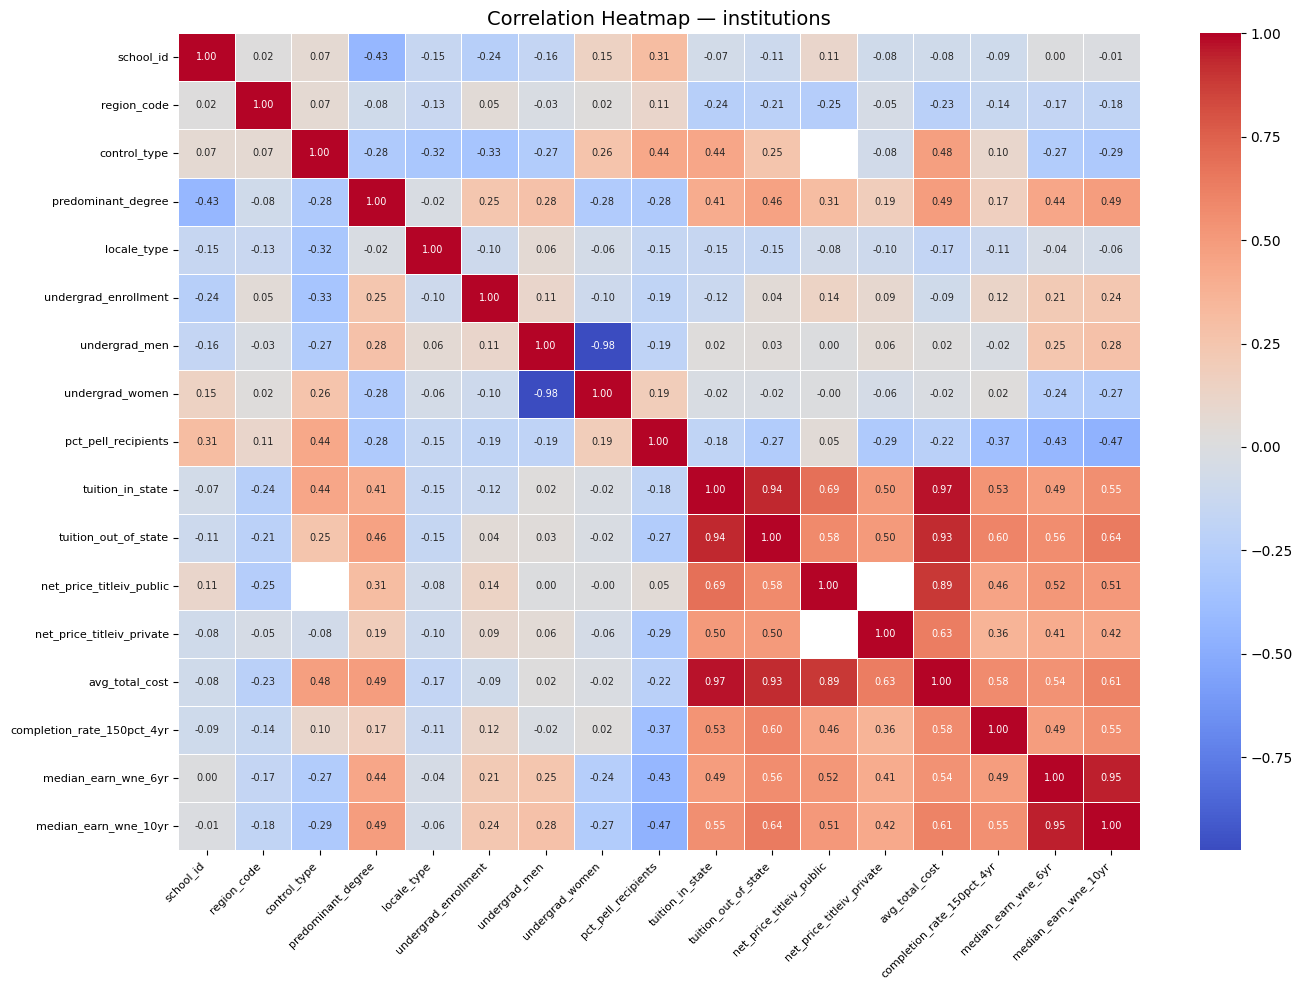

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# utilitze number data only
numeric_df = df_inst.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 7}
)

plt.title('Correlation Heatmap — institutions', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Update "PS", "NULL", "NaN", "N/A", "" to NaN which works better in Python

In [43]:
import numpy as np
missing_values = ["PS", "NULL", "NaN", "N/A", ""]
df_inst = df_inst.replace(missing_values, np.nan)

### Review the first 4 rows to make sure the data is clean and looks the way I expected

In [44]:
df_inst.head()

,school_id,school_name,state,region_code,control_type,predominant_degree,locale_type,undergrad_enrollment,undergrad_men,undergrad_women,...,median_family_income,tuition_in_state,tuition_out_of_state,net_price_titleiv_public,net_price_titleiv_private,avg_total_cost,completion_rate_150pct_4yr,median_earn_wne_6yr,median_earn_wne_10yr,median_debt_stafford_grad_plus
0,100654,Alabama A & M University,AL,5,1,3,12.0,6124.0,0.4221,0.5779,...,32362.826114,10024.0,18634.0,17621.0,NaN,27153.0,0.2403,27851.0,40628.0,16600
1,100663,University of Alabama at Birmingham,AL,5,1,3,12.0,11635.0,0.3680,0.6320,...,51306.674306,9098.0,22562.0,18749.0,NaN,28145.0,0.6423,46572.0,54501.0,15832
2,100690,Amridge University,AL,5,2,3,12.0,241.0,0.3444,0.6556,...,21079.472973,7590.0,7590.0,NaN,NaN,NaN,1.0000,30377.0,37621.0,13385
3,100706,University of Alabama in Huntsville,AL,5,1,3,12.0,6591.0,0.6095,0.3905,...,61096.588949,12132.0,26408.0,18796.0,NaN,27392.0,0.6429,55610.0,61767.0,13905
4,100724,Alabama State University,AL,5,1,3,12.0,3477.0,0.3653,0.6347,...,31684.382188,11248.0,19576.0,20435.0,NaN,23586.0,0.3034,27453.0,34502.0,17500


### Updating null values to None because this is easier for SQL to ingest

In [45]:

df_inst = df_inst.replace(["PS", "NULL", "NA", "N/A", ""], np.nan)
df_inst = df_inst.where(pd.notnull(df_inst), None)

print(df_inst.head())

   school_id                          school_name state  region_code  \
0     100654             Alabama A & M University    AL            5   
1     100663  University of Alabama at Birmingham    AL            5   
2     100690                   Amridge University    AL            5   
3     100706  University of Alabama in Huntsville    AL            5   
4     100724             Alabama State University    AL            5   

   control_type  predominant_degree  locale_type  undergrad_enrollment  \
0             1                   3         12.0                6124.0   
1             1                   3         12.0               11635.0   
2             2                   3         12.0                 241.0   
3             1                   3         12.0                6591.0   
4             1                   3         12.0                3477.0   

   undergrad_men  undergrad_women  ...  median_family_income tuition_in_state  \
0         0.4221           0.5779  ...   

In [46]:
df_inst.head()

,school_id,school_name,state,region_code,control_type,predominant_degree,locale_type,undergrad_enrollment,undergrad_men,undergrad_women,...,median_family_income,tuition_in_state,tuition_out_of_state,net_price_titleiv_public,net_price_titleiv_private,avg_total_cost,completion_rate_150pct_4yr,median_earn_wne_6yr,median_earn_wne_10yr,median_debt_stafford_grad_plus
0,100654,Alabama A & M University,AL,5,1,3,12.0,6124.0,0.4221,0.5779,...,32362.826114,10024.0,18634.0,17621.0,NaN,27153.0,0.2403,27851.0,40628.0,16600
1,100663,University of Alabama at Birmingham,AL,5,1,3,12.0,11635.0,0.3680,0.6320,...,51306.674306,9098.0,22562.0,18749.0,NaN,28145.0,0.6423,46572.0,54501.0,15832
2,100690,Amridge University,AL,5,2,3,12.0,241.0,0.3444,0.6556,...,21079.472973,7590.0,7590.0,NaN,NaN,NaN,1.0000,30377.0,37621.0,13385
3,100706,University of Alabama in Huntsville,AL,5,1,3,12.0,6591.0,0.6095,0.3905,...,61096.588949,12132.0,26408.0,18796.0,NaN,27392.0,0.6429,55610.0,61767.0,13905
4,100724,Alabama State University,AL,5,1,3,12.0,3477.0,0.3653,0.6347,...,31684.382188,11248.0,19576.0,20435.0,NaN,23586.0,0.3034,27453.0,34502.0,17500


### Ingesting the data for the programs data frame

In [47]:
import pandas as pd
df_programs = pd.read_csv('data/Most-Recent-Cohorts-Field-of-Study.csv', low_memory=False)

### Taking a look at the programs data

In [48]:
df_programs.info()

<class 'pandas.DataFrame'>
RangeIndex: 227980 entries, 0 to 227979
Columns: 178 entries, UNITID to EARN_P75_4YR_NAT
dtypes: float64(3), int64(5), str(170)
memory usage: 309.6 MB


In [49]:
df_programs.head()

,UNITID,OPEID6,INSTNM,CONTROL,MAIN,CIPCODE,CIPDESC,CREDLEV,CREDDESC,IPEDSCOUNT1,...,EARN_COUNT_MALE_WNE_5YR,EARN_MALE_WNE_MDN_5YR,EARN_COUNT_NOMALE_WNE_5YR,EARN_NOMALE_WNE_MDN_5YR,EARN_COUNT_HIGH_CRED_5YR,EARN_IN_STATE_5YR,EARN_COUNT_WNE_4YR_NAT,EARN_MDN_4YR_NAT,EARN_P25_4YR_NAT,EARN_P75_4YR_NAT
0,100654.0,1002,Alabama A & M University,Public,1,109,Animal Sciences.,3,Bachelor's Degree,9.0,...,PS,PS,PS,PS,PS,PS,6104,49634,36349,66880
1,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,3,Bachelor's Degree,7.0,...,PS,PS,PS,PS,PS,PS,1301,70873,54113,88238
2,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,5,Master's Degree,7.0,...,PS,PS,PS,PS,PS,PS,380,88332,65085,115796
3,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,6,Doctoral Degree,3.0,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS
4,100654.0,1002,Alabama A & M University,Public,1,199,Agricultural/Animal/Plant/Veterinary Science a...,3,Bachelor's Degree,1.0,...,PS,PS,PS,PS,PS,PS,413,65543,46023,83774


## Checking for null and duplicated data

In [50]:
print(df_programs.duplicated().sum())

0


In [51]:
print(df_programs.isnull().sum())

UNITID                     7020
OPEID6                        0
INSTNM                        0
CONTROL                       0
MAIN                          0
                          ...  
EARN_IN_STATE_5YR         19411
EARN_COUNT_WNE_4YR_NAT        0
EARN_MDN_4YR_NAT              0
EARN_P25_4YR_NAT              0
EARN_P75_4YR_NAT              0
Length: 178, dtype: int64


### Update "PS", "NULL", "NaN", "N/A", "" to NaN which works better in Python

In [52]:
import numpy as np
missing_values = ["PS", "NULL", "NaN", "N/A", ""]
df_programs = df_programs.replace(missing_values, np.nan)

### Used Claude AI to rename column names from the dataset to logical names and create a data dictionary

In [53]:
PROGRAM_COLUMNS = {
    'UNITID':                    'school_id',
    'CIPCODE':                   'cip_code',
    'CIPDESC':                   'program_name',
    'CREDLEV':                   'cred_level',
    'CREDDESC':                  'cred_label',
    'DEBT_ALL_STGP_ANY_MDN':     'median_debt_stafford_grad_plus',
    'DEBT_MALE_STGP_ANY_MDN':    'median_debt_male_stafford_grad_plus',
    'DEBT_NOTMALE_STGP_ANY_MDN': 'median_debt_female_stafford_grad_plus',
    'EARN_MDN_1YR':              'median_earn_wne_1yr',
    'EARN_MDN_4YR':              'median_earn_wne_4yr',
    'EARN_MDN_5YR':              'median_earn_wne_5yr',
    'EARN_MALE_WNE_MDN_1YR':     'median_earn_male_wne_1yr',
    'EARN_MALE_WNE_MDN_4YR':     'median_earn_male_wne_4yr',
    'EARN_NOMALE_WNE_MDN_1YR':   'median_earn_female_wne_1yr',
    'EARN_NOMALE_WNE_MDN_4YR':   'median_earn_female_wne_4yr',
    'EARN_PELL_WNE_MDN_1YR':     'median_earn_pell_wne_1yr',
    'EARN_NOPELL_WNE_MDN_1YR':   'median_earn_nopell_wne_1yr',
    'EARN_PELL_WNE_MDN_4YR':     'median_earn_pell_wne_4yr',
    'EARN_NOPELL_WNE_MDN_4YR':   'median_earn_nopell_wne_4yr',
}

In [54]:
df_programs = df_programs[list(PROGRAM_COLUMNS.keys())].rename(columns=PROGRAM_COLUMNS)
print(df_programs.shape)

(227980, 19)


In [73]:
import pandas as pd
df_awards= pd.read_csv('data/c2024_a.csv', low_memory=False)

In [74]:
print(df_awards.duplicated().sum())

0


### Ingesting the data for the awards data frame

In [75]:
print(df_awards.isnull().sum())

UNITID      0
CIPCODE     0
MAJORNUM    0
AWLEVEL     0
XCTOTALT    0
           ..
CNRALT      0
XCNRALM     0
CNRALM      0
XCNRALW     0
CNRALW      0
Length: 64, dtype: int64


### Update "PS", "NULL", "NaN", "N/A", "" to NaN which works better in Python

In [76]:
import numpy as np
missing_values = ["PS", "NULL", "NaN", "N/A", ""]
df_awards = df_awards.replace(missing_values, np.nan)

### Used Claude AI to rename column names from the dataset to logical names and create a data dictionary

In [77]:
AWARDS_COLUMNS = {
    'UNITID':   'school_id',
    'CIPCODE':  'cip_code',
    'MAJORNUM': 'major_num',
    'AWLEVEL':  'award_level',
    'CTOTALT':  'completions_total',
    'CTOTALM':  'completions_male',
    'CTOTALW':  'completions_female',
}

In [78]:
df_awards = df_awards[list(AWARDS_COLUMNS.keys())].rename(columns=AWARDS_COLUMNS)
print(df_awards.shape)

(307707, 7)


 ### drop duplicates for each key (key combo) to ensure those values are unique

In [79]:
df_inst = df_inst.drop_duplicates(subset=['school_id'])
df_programs = df_programs.drop_duplicates(subset=['school_id', 'cip_code', 'cred_level'])
df_awards = df_awards.drop_duplicates(subset=['school_id', 'cip_code', 'award_level'])

### import panda libraries and  SQLite3

In [80]:
import sqlite3
import pandas as pd
import os

### Create a database bath and connect

In [63]:
DB_PATH = os.path.join('data', 'student_performance.db')
connection = sqlite3.connect(DB_PATH)
cursor = connection.cursor()
print('Connected to:', DB_PATH)

Connected to: data\student_performance.db


### drop the tables if they already exist (in the right sequence because of FK dependency). This way the script can be re-executed even if the database was already created

In [85]:
cursor.execute('DROP TABLE IF EXISTS awards;')
cursor.execute('DROP TABLE IF EXISTS programs;')
cursor.execute('DROP TABLE IF EXISTS institutions;')
print('Existing tables dropped.')

Existing tables dropped.


### create institutions, programs, awards tables. used Claude AI for formatting

In [86]:
cursor.execute('''
    CREATE TABLE institutions (
        school_id                      INTEGER PRIMARY KEY,
        school_name                    TEXT,
        state                          TEXT,
        region_code                    INTEGER,
        control_type                   INTEGER,
        predominant_degree             INTEGER,
        locale_type                    INTEGER,
        undergrad_enrollment           REAL,
        undergrad_men                  REAL,
        undergrad_women                REAL,
        pct_pell_recipients            REAL,
        median_family_income           REAL,
        tuition_in_state               REAL,
        tuition_out_of_state           REAL,
        net_price_titleiv_public       REAL,
        net_price_titleiv_private      REAL,
        avg_total_cost                 REAL,
        completion_rate_150pct_4yr     REAL,
        median_earn_wne_6yr            REAL,
        median_earn_wne_10yr           REAL,
        median_debt_stafford_grad_plus REAL
    );
''')
print('institutions table created.')

institutions table created.


In [87]:
cursor.execute('''
    CREATE TABLE programs (
        program_id                            INTEGER PRIMARY KEY AUTOINCREMENT,
        school_id                             INTEGER,
        cip_code                              TEXT,
        program_name                          TEXT,
        cred_level                            INTEGER,
        cred_label                            TEXT,
        median_debt_stafford_grad_plus        REAL,
        median_debt_male_stafford_grad_plus   REAL,
        median_debt_female_stafford_grad_plus REAL,
        median_earn_wne_1yr                   REAL,
        median_earn_wne_4yr                   REAL,
        median_earn_wne_5yr                   REAL,
        median_earn_male_wne_1yr              REAL,
        median_earn_male_wne_4yr              REAL,
        median_earn_female_wne_1yr            REAL,
        median_earn_female_wne_4yr            REAL,
        median_earn_pell_wne_1yr              REAL,
        median_earn_nopell_wne_1yr            REAL,
        median_earn_pell_wne_4yr              REAL,
        median_earn_nopell_wne_4yr            REAL,
        FOREIGN KEY (school_id) REFERENCES institutions(school_id),
        UNIQUE (school_id, cip_code, cred_level)
    );
''')
print('programs table created.')

programs table created.


In [88]:
cursor.execute('''
    CREATE TABLE awards (
        award_id           INTEGER PRIMARY KEY AUTOINCREMENT,
        school_id          INTEGER,
        cip_code           TEXT,
        cred_level         INTEGER,
        award_level        INTEGER,
        completions_total  INTEGER,
        completions_male   INTEGER,
        completions_female INTEGER,
        FOREIGN KEY (school_id) REFERENCES institutions(school_id),
        UNIQUE (school_id, cip_code, award_level)
    );
''')
print('awards table created.')

awards table created.


### Append data to the data frames created above and print the number of rows added (this allows additional rows to be added without replacing)

In [89]:
df_inst.to_sql('institutions', connection, if_exists='append', index=False)
print(f'institutions inserted: {len(df_inst):,} rows')

institutions inserted: 6,322 rows


In [90]:
df_programs.to_sql('programs', connection, if_exists='append', index=False)
print(f'programs inserted: {len(df_programs):,} rows')

programs inserted: 221,947 rows


In [92]:
df_awards = df_awards[df_awards['major_num'] == 1].drop(columns=['major_num'])

In [93]:
df_awards.to_sql('awards', connection, if_exists='append', index=False)
print(f'awards inserted: {len(df_awards):,} rows')

awards inserted: 286,979 rows


### Close the connection for cleanup

In [94]:
connection.close()
print('Connection closed.')

Connection closed.


### Code for connecting the the database after its already been created

In [1]:
import sqlite3
import pandas as pd
import os

connection = sqlite3.connect('data/student_performance.db')
cursor = connection.cursor()
print('Connected to:', 'data/student_performance.db')

Connected to: data/student_performance.db


### Query to test that my new database works and yay! it does

In [10]:
pd.read_sql('SELECT * FROM programs', connection)

,program_id,school_id,cip_code,program_name,cred_level,cred_label,median_debt_stafford_grad_plus,median_debt_male_stafford_grad_plus,median_debt_female_stafford_grad_plus,median_earn_wne_1yr,median_earn_wne_4yr,median_earn_wne_5yr,median_earn_male_wne_1yr,median_earn_male_wne_4yr,median_earn_female_wne_1yr,median_earn_female_wne_4yr,median_earn_pell_wne_1yr,median_earn_nopell_wne_1yr,median_earn_pell_wne_4yr,median_earn_nopell_wne_4yr
0,1,100654.0,109,Animal Sciences.,3,Bachelor's Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,100654.0,110,Food Science and Technology.,3,Bachelor's Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,100654.0,110,Food Science and Technology.,5,Master's Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,100654.0,110,Food Science and Technology.,6,Doctoral Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,100654.0,199,Agricultural/Animal/Plant/Veterinary Science a...,3,Bachelor's Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221942,221943,NaN,2401,"Liberal Arts and Sciences, General Studies and...",8,Graduate/Professional Certificate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221943,221944,NaN,4201,"Psychology, General.",8,Graduate/Professional Certificate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221944,221945,NaN,4599,"Social Sciences, Other.",8,Graduate/Professional Certificate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
221945,221946,NaN,4228,"Clinical, Counseling and Applied Psychology.",7,First Professional Degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### This is a SQL Query designed to show me the earnings gap between men and women by degree and then rank them to show the largest gap by degree

In [45]:
df_ranking = pd.read_sql('''
     select *
    from (
        select program_name,
               cred_label,
               ROUND(avg_earn_male, 0) AS avg_earnings_for_a_man,
               ROUND(avg_earn_female, 0) AS avg_earnings_for_a_female,
               ROUND(earnings_gap, 0) AS earnings_gap,
               rank() over (partition by cred_level order by earnings_gap desc) as rank_within_cred_level
        from (
                select p.program_name,
                   p.cred_label,
                   p.cred_level,
                   avg(p.median_earn_male_wne_4yr) as avg_earn_male,
                   avg(p.median_earn_female_wne_4yr) as avg_earn_female,
                   avg(p.median_earn_male_wne_4yr)- avg(p.median_earn_female_wne_4yr) as earnings_gap
                from programs p
                where p.median_earn_male_wne_4yr IS NOT NULL
                and p.median_earn_female_wne_4yr IS NOT NULL
                group by p.program_name, p.cred_label, p.cred_level
        )
    )
    where rank_within_cred_level <= 6
    order by rank_within_cred_level, rank_within_cred_level
''', connection)
display(df_ranking)

,program_name,cred_label,avg_earnings_for_a_man,avg_earnings_for_a_female,earnings_gap,rank_within_cred_level
0,Natural Sciences.,Undergraduate Certificate or Diploma,58650.0,33418.0,25232.0,1
1,Physical Science Technologies/Technicians.,Associate's Degree,100461.0,47224.0,53237.0,1
2,"Engineering, General.",Bachelor's Degree,109335.0,86798.0,22537.0,1
3,Public Health.,Post-baccalaureate Certificate,91132.0,79067.0,12065.0,1
4,Real Estate.,Master's Degree,148708.0,114747.0,33961.0,1
5,Chemistry.,Doctoral Degree,117909.0,80674.0,37235.0,1
6,"Registered Nursing, Nursing Administration, Nu...",First Professional Degree,183741.0,129047.0,54695.0,1
7,Advanced/Graduate Dentistry and Oral Sciences.,Graduate/Professional Certificate,207391.0,148809.0,58582.0,1
8,"Specialized Sales, Merchandising and Marketin...",Undergraduate Certificate or Diploma,50967.0,28493.0,22474.0,2
9,Industrial Production Technologies/Technicians.,Associate's Degree,87997.0,47877.0,40120.0,2


### This bar chart is designed to show the earnings gap by degree for men and women. The top earning gaps are in dental, nursing. IS, legal professions and chemistry. $60.000 is a staggering earnings gap for dentists.

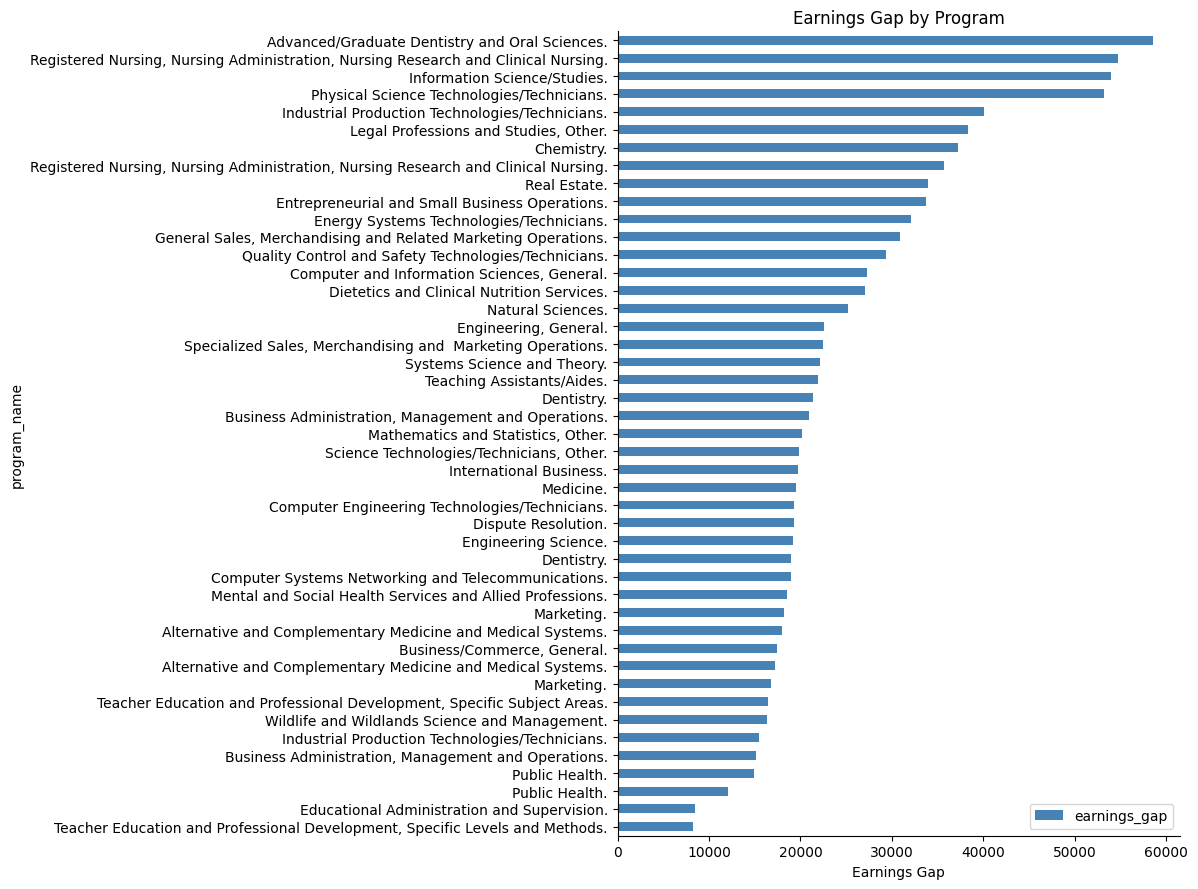

In [44]:
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt

df_sorted = df_ranking.sort_values('earnings_gap', ascending=True)

df_sorted.plot(kind='barh', x='program_name', y='earnings_gap', figsize=(12, 9), color='steelblue')
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.title("Earnings Gap by Program")
plt.xlabel("Earnings Gap")
plt.tight_layout()
plt.show()

### This bar chart is designed to show the side by side disparity in earnings by gender and degree. The above chart aggregates the gap and the below chart breaks it down into more detail.

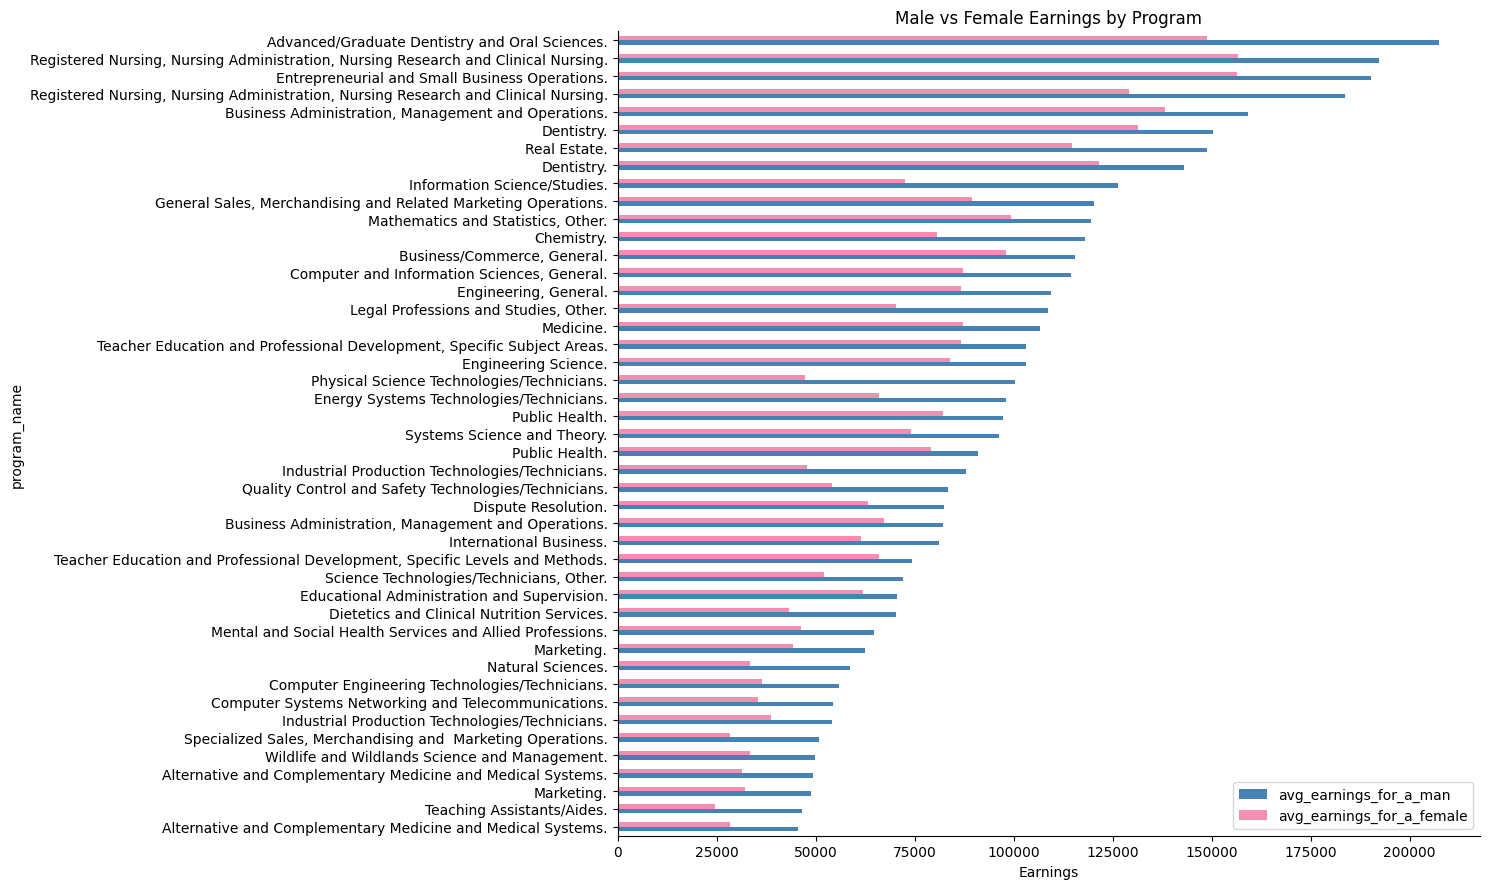

In [43]:
import matplotlib.pyplot as plt

df_sorted = df_ranking.sort_values('avg_earnings_for_a_man', ascending=True)

df_sorted[['program_name', 'avg_earnings_for_a_man', 'avg_earnings_for_a_female']].plot( kind='barh', x='program_name', figsize=(15, 9),color=['steelblue', '#F48FB1']
)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.title("Male vs Female Earnings by Program")
plt.xlabel("Earnings")
plt.tight_layout()
plt.show()

In [ ]:
df_school_debt = pd.read_sql('''
    select i.school_name,
           i.state,
           case i.control_type
               when 1 THEN 'Public'
               when 2 THEN 'Private Non-Profit'
               when 3 THEN 'Private For-Profit'
                end AS school_type,
           COUNT(*) AS program_count,
           ROUND(AVG(p.median_debt_stafford_grad_plus), 0) AS avg_debt,
           ROUND(AVG(p.median_earn_wne_4yr), 0) AS avg_earn_4yr,
           ROUND(AVG(p.median_debt_stafford_grad_plus)
               / AVG(p.median_earn_wne_4yr), 2) AS debt_to_income_ratio
    FROM programs p
    JOIN institutions i ON p.school_id = i.school_id
    WHERE p.median_earn_wne_4yr IS NOT NULL
      AND p.median_debt_stafford_grad_plus IS NOT NULL
      AND p.median_earn_wne_4yr > 0
    GROUP BY i.school_id, i.school_name, i.state, i.control_type
    ORDER BY debt_to_income_ratio DESC
    LIMIT 20
''', connection)
display(df_school_debt)

,school_name,state,school_type,program_count,avg_debt,avg_earn_4yr,debt_to_income_ratio
0,Shorter College,AR,Private Non-Profit,1,37242.0,26650.0,1.40
1,Nossi College of Art and Design,TN,Private For-Profit,1,46500.0,35075.0,1.33
2,LaBarberia Institute of Hair,OH,Private For-Profit,1,20000.0,16321.0,1.23
3,Old Town Barber College,KS,Private For-Profit,1,14125.0,11857.0,1.19
4,Sandra Academy of Salon Services,TN,Private For-Profit,1,14831.0,12724.0,1.17
5,American College of Healthcare Sciences,OR,Private For-Profit,2,30012.0,27662.0,1.08
6,Associated Barber College of San Diego,CA,Private For-Profit,1,16395.0,15201.0,1.08
7,Allen University,SC,Private Non-Profit,4,39771.0,37177.0,1.07
8,Southern University at New Orleans,LA,Public,6,47418.0,44543.0,1.06
9,Saint Augustine's University,NC,Private Non-Profit,1,40375.0,38086.0,1.06
